# Face Recognition with PCA
**ORL/ATT Dataset — 40 subjects × 10 images each**

## 1. Imports

In [25]:
import os
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from PIL import Image
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

## 2. Load Dataset → Data Matrix D and Label Vector y

In [26]:
base_path = kagglehub.dataset_download("kasikrit/att-database-of-faces")

if os.path.exists(os.path.join(base_path, "s1")):
    DATASET_PATH = base_path
else:
    DATASET_PATH = os.path.join(base_path, "files")

IMG_H, IMG_W = 112, 92
N_SUBJECTS  = 40
N_PER_SUBJ  = 10

D = np.zeros((N_SUBJECTS * N_PER_SUBJ, IMG_H * IMG_W), dtype=np.float64)
y = np.zeros(N_SUBJECTS * N_PER_SUBJ, dtype=np.int32)

row = 0
for subject_id in range(1, N_SUBJECTS + 1):
    subject_dir = os.path.join(DATASET_PATH, f"s{subject_id}")

    for img_idx in range(1, N_PER_SUBJ + 1):
        img_path = os.path.join(subject_dir, f"{img_idx}.pgm")

        with Image.open(img_path) as img:
            img = img.convert("L")  # grayscale
            D[row] = np.array(img, dtype=np.float64).flatten()
            y[row] = subject_id
            row += 1

print(f"Data matrix shape : {D.shape}")
print(f"Label vector shape: {y.shape}")
print(f"Label range       : {y.min()} – {y.max()}")

Using Colab cache for faster access to the 'att-database-of-faces' dataset.
Data matrix shape : (400, 10304)
Label vector shape: (400,)
Label range       : 1 – 40


## 3. Train / Test Split (odd rows → train, even rows → test)

In [27]:
# Row indices are 0-based; "odd" in 1-based means index 0,2,4,6,8 (every other starting from 0 within each block)
# Within each subject block of 10, keep positions 0,2,4,6,8 for train and 1,3,5,7,9 for test
train_idx = []
test_idx  = []

for subject_id in range(N_SUBJECTS):
    base = subject_id * N_PER_SUBJ
    for i in range(N_PER_SUBJ):
        # 1-based position: i+1; odd → train, even → test
        if (i + 1) % 2 == 1:   # odd
            train_idx.append(base + i)
        else:                   # even
            test_idx.append(base + i)

X_train, y_train = D[train_idx], y[train_idx]
X_test,  y_test  = D[test_idx],  y[test_idx]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (200, 10304), Test: (200, 10304)


## 4. PCA Implementation (from scratch)

Steps:
1. Compute the mean face from the **training** set.
2. Center the data.
3. Compute the covariance matrix (using the trick for high-dimensional data).
4. Compute eigenvalues / eigenvectors.
5. Save eigenvalues to `.npy` for reuse.

In [28]:
EIGEN_FILE = "eigenvalues.npy"
EIGENVEC_FILE = "eigenvectors.npy"

# --- Step 1: Mean face ---
mean_face = X_train.mean(axis=0)   # shape (10304,)

# --- Step 2: Center ---
X_centered = X_train - mean_face   # shape (200, 10304)

# --- Step 3 & 4: Eigendecomposition using the small covariance trick ---
# Instead of cov = X_centered.T @ X_centered  (10304×10304),
# compute  A = X_centered @ X_centered.T  (200×200) and recover eigenvectors.
if os.path.exists(EIGEN_FILE) and os.path.exists(EIGENVEC_FILE):
    print("Loading cached eigenvalues/vectors...")
    eigenvalues  = np.load(EIGEN_FILE)
    eigenvectors = np.load(EIGENVEC_FILE)
else:
    print("Computing eigendecomposition...")
    n = X_centered.shape[0]                          # 200
    A = (X_centered @ X_centered.T) / (n - 1)       # 200×200
    eigenvalues, v = np.linalg.eigh(A)               # v: 200×200

    # Sort descending
    idx          = np.argsort(eigenvalues)[::-1]
    eigenvalues  = eigenvalues[idx]
    v            = v[:, idx]

    # Map back to original space: u_i = X_centered.T @ v_i  (then normalise)
    eigenvectors = X_centered.T @ v                  # shape (10304, 200)
    norms        = np.linalg.norm(eigenvectors, axis=0, keepdims=True)
    eigenvectors = eigenvectors / norms

    # Keep only positive eigenvalues
    pos_mask     = eigenvalues > 0
    eigenvalues  = eigenvalues[pos_mask]
    eigenvectors = eigenvectors[:, pos_mask]

    np.save(EIGEN_FILE,    eigenvalues)
    np.save(EIGENVEC_FILE, eigenvectors)
    print("Saved to disk.")

print(f"Number of positive eigenvalues: {len(eigenvalues)}")
print(f"Eigenvectors shape            : {eigenvectors.shape}")

Loading cached eigenvalues/vectors...
Number of positive eigenvalues: 199
Eigenvectors shape            : (10304, 199)


## 5. Variance Retention & Dimensionality per α

In [29]:
alphas = [0.80, 0.85, 0.90, 0.95]

cumvar = np.cumsum(eigenvalues) / np.sum(eigenvalues)

print(f"{'α':>6}  {'k (components)':>16}")
print("-" * 26)
k_per_alpha = {}
for alpha in alphas:
    k = int(np.searchsorted(cumvar, alpha)) + 1
    k_per_alpha[alpha] = k
    print(f"{alpha:>6.2f}  {k:>16}")

     α    k (components)
--------------------------
  0.80                36
  0.85                51
  0.90                76
  0.95               115


### Scree plot — cumulative explained variance

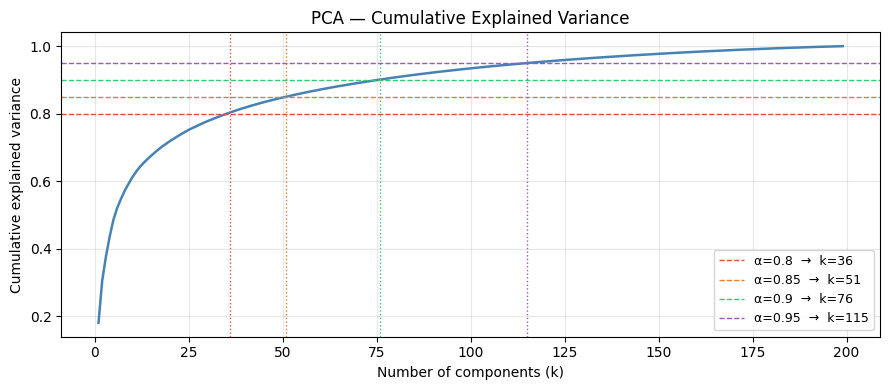

In [30]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(1, len(cumvar) + 1), cumvar, linewidth=1.8, color="steelblue")

colors = ["#e74c3c", "#e67e22", "#2ecc71", "#9b59b6"]
for (alpha, k), color in zip(k_per_alpha.items(), colors):
    ax.axhline(alpha, color=color, linestyle="--", linewidth=1, label=f"α={alpha}  →  k={k}")
    ax.axvline(k,     color=color, linestyle=":",  linewidth=1)

ax.set_xlabel("Number of components (k)")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA — Cumulative Explained Variance")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Project Data into PCA Subspace (all α values)

In [31]:
def pca_project(X, mean_face, eigenvectors, k):
    """Center X and project onto the first k eigenvectors."""
    X_c = X - mean_face
    return X_c @ eigenvectors[:, :k]   # shape (n_samples, k)

projections = {}
for alpha in alphas:
    k = k_per_alpha[alpha]
    projections[alpha] = {
        "k"       : k,
        "train"   : pca_project(X_train, mean_face, eigenvectors, k),
        "test"    : pca_project(X_test,  mean_face, eigenvectors, k),
    }
    print(f"α={alpha}  k={k:3d}  train_proj={projections[alpha]['train'].shape}  test_proj={projections[alpha]['test'].shape}")

α=0.8  k= 36  train_proj=(200, 36)  test_proj=(200, 36)
α=0.85  k= 51  train_proj=(200, 51)  test_proj=(200, 51)
α=0.9  k= 76  train_proj=(200, 76)  test_proj=(200, 76)
α=0.95  k=115  train_proj=(200, 115)  test_proj=(200, 115)


## 7. Visualise Sample Faces Reconstructed from PCA Subspace

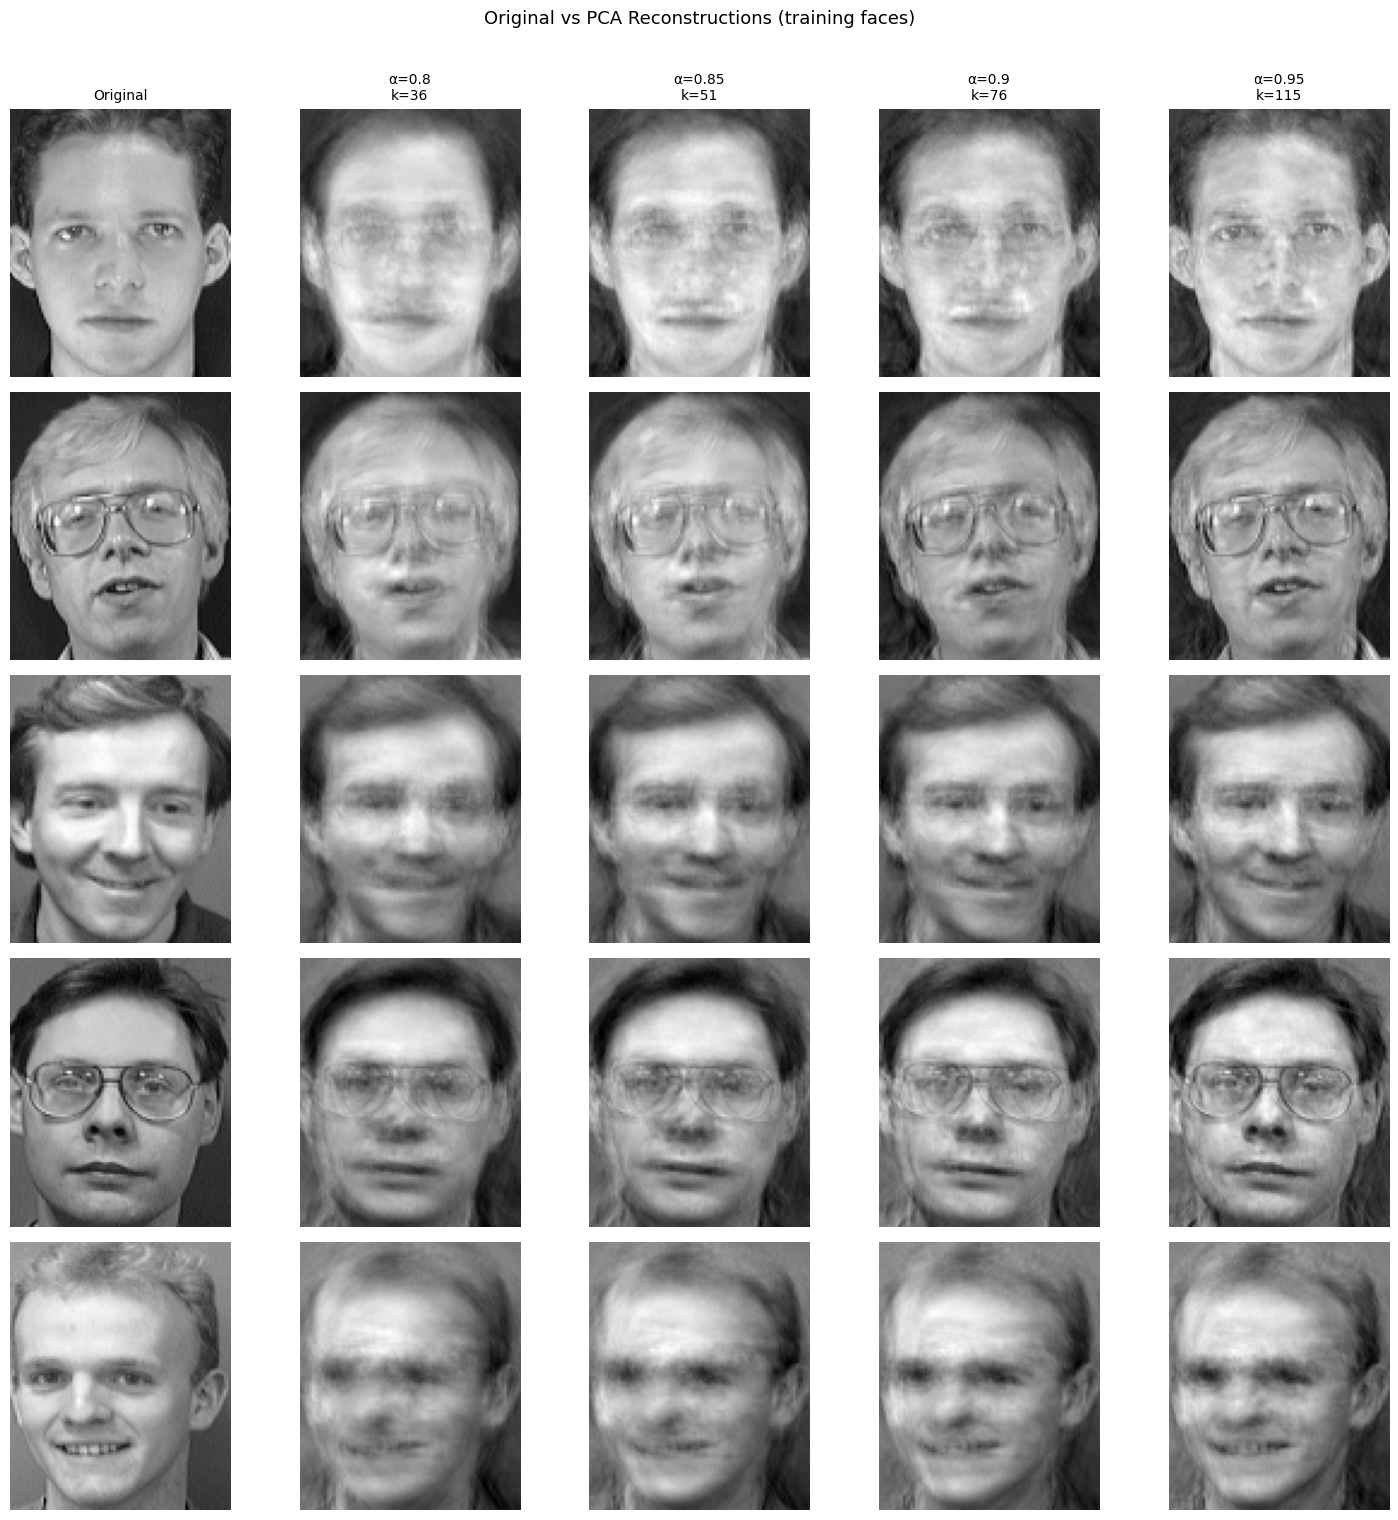

In [32]:
def reconstruct(proj, mean_face, eigenvectors):
    """Reconstruct faces from PCA projection."""
    k = proj.shape[1]
    return proj @ eigenvectors[:, :k].T + mean_face

N_SHOW = 5   # number of sample subjects to show
sample_rows = [i * N_PER_SUBJ // 2 for i in range(N_SHOW)]   # one image per subject from train

fig, axes = plt.subplots(N_SHOW, len(alphas) + 1,
                         figsize=(3 * (len(alphas) + 1), 3 * N_SHOW))

for row_i, row_idx in enumerate(sample_rows):
    # Original
    ax = axes[row_i, 0]
    ax.imshow(X_train[row_idx].reshape(IMG_H, IMG_W), cmap="gray")
    ax.axis("off")
    if row_i == 0:
        ax.set_title("Original", fontsize=10)

    # Reconstructions
    for col_i, alpha in enumerate(alphas):
        k    = projections[alpha]["k"]
        proj = projections[alpha]["train"][row_idx:row_idx+1]
        rec  = reconstruct(proj, mean_face, eigenvectors)[0]
        ax   = axes[row_i, col_i + 1]
        ax.imshow(rec.reshape(IMG_H, IMG_W), cmap="gray")
        ax.axis("off")
        if row_i == 0:
            ax.set_title(f"α={alpha}\nk={k}", fontsize=10)

plt.suptitle("Original vs PCA Reconstructions (training faces)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. Visualise the Mean Face and Top Eigenfaces

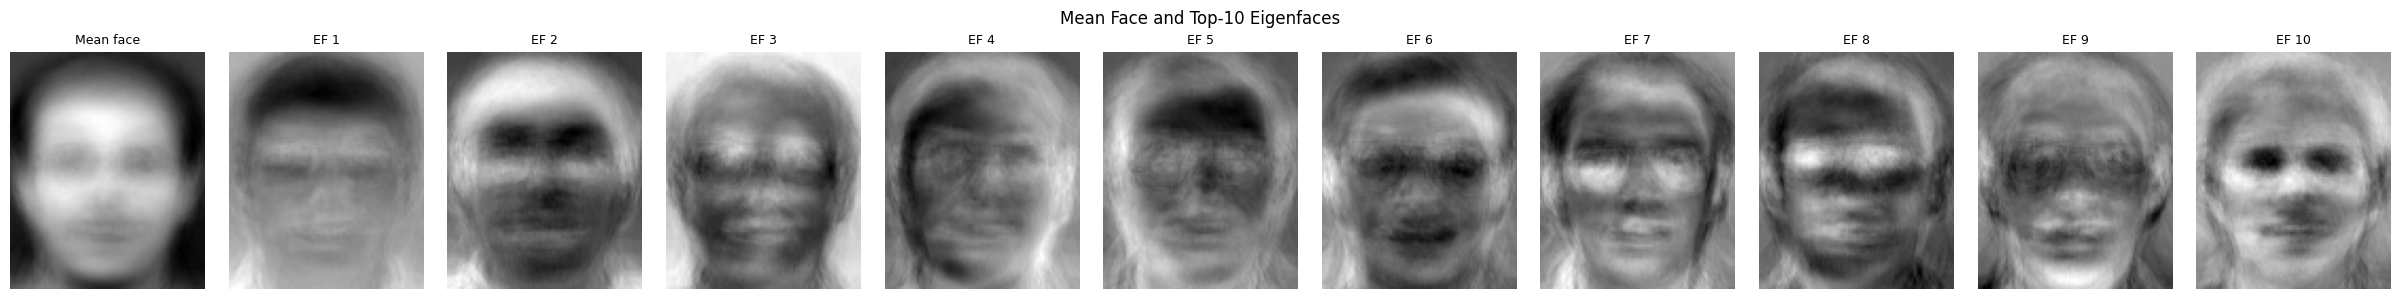

In [33]:
N_EIGENFACES = 10
fig, axes = plt.subplots(1, N_EIGENFACES + 1, figsize=(2.2 * (N_EIGENFACES + 1), 3))

axes[0].imshow(mean_face.reshape(IMG_H, IMG_W), cmap="gray")
axes[0].set_title("Mean face", fontsize=9)
axes[0].axis("off")

for i in range(N_EIGENFACES):
    ef = eigenvectors[:, i].reshape(IMG_H, IMG_W)
    axes[i + 1].imshow(ef, cmap="gray")
    axes[i + 1].set_title(f"EF {i+1}", fontsize=9)
    axes[i + 1].axis("off")

plt.suptitle("Mean Face and Top-10 Eigenfaces", fontsize=12)
plt.tight_layout()
plt.show()

## 9. Summary Table

In [34]:
print(f"{'α':>6}  {'k':>6}  {'Variance retained':>20}")
print("-" * 37)
for alpha in alphas:
    k        = k_per_alpha[alpha]
    retained = cumvar[k - 1] * 100
    print(f"{alpha:>6.2f}  {k:>6}  {retained:>19.2f}%")

     α       k     Variance retained
-------------------------------------
  0.80      36                80.36%
  0.85      51                85.06%
  0.90      76                90.13%
  0.95     115                95.01%


---
## K-Means Clustering

### Implementation

In [35]:
def kmeans_fit(X, K, max_iter=100):
    n = len(X)
    # random initial centroids
    idx = np.random.choice(n, K, replace=False)
    centroids = X[idx]

    labels = np.zeros(n, dtype=int)

    for _ in range(max_iter):
        for i in range(n):
            distances = [np.linalg.norm(X[i] - c) for c in centroids]
            labels[i] = np.argmin(distances)

        new_centroids = []
        for k in range(K):
            points = X[labels == k]
            if len(points) > 0:
                new_centroids.append(np.mean(points, axis=0))
            else:
                new_centroids.append(centroids[k])
        new_centroids = np.array(new_centroids)

        # stop if no change
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids

    return centroids, labels

Prediction

In [36]:
def kmeans_predict(X, centroids):
    preds = []
    for x in X:
        distances = [np.linalg.norm(x - c) for c in centroids]
        preds.append(np.argmin(distances))
    return np.array(preds)

Clustering Accuracy

In [37]:
def clustering_accuracy(y_true, y_pred):
    K = max(max(y_true), max(y_pred)) + 1
    matrix = np.zeros((K, K), dtype=int)
    for p, t in zip(y_pred, y_true):
        matrix[p][t] += 1
    row_ind, col_ind = linear_sum_assignment(-matrix)
    correct = sum(matrix[r][c] for r, c in zip(row_ind, col_ind))
    return correct / len(y_true)

In [38]:
K_values = [20, 40, 60]
results = []

for alpha in alphas:
    X_train = projections[alpha]['train']
    for K in K_values:
        centroids, labels = kmeans_fit(X_train, K)
        acc = clustering_accuracy(y_train, labels)
        results.append((alpha, K, acc))
        print(f"alpha={alpha}, K={K}, acc={acc:.4f}")

alpha=0.8, K=20, acc=0.4500
alpha=0.8, K=40, acc=0.7350
alpha=0.8, K=60, acc=0.6600
alpha=0.85, K=20, acc=0.4300
alpha=0.85, K=40, acc=0.6500
alpha=0.85, K=60, acc=0.6450
alpha=0.9, K=20, acc=0.3950
alpha=0.9, K=40, acc=0.5800
alpha=0.9, K=60, acc=0.6500
alpha=0.95, K=20, acc=0.4200
alpha=0.95, K=40, acc=0.6100
alpha=0.95, K=60, acc=0.6000


Accuracy vs K

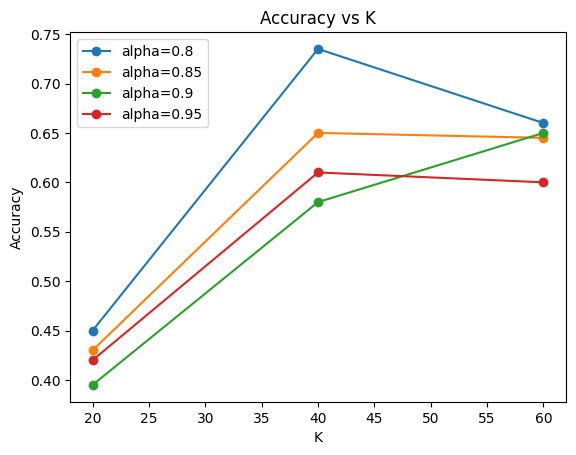

In [39]:
for alpha in alphas:
    ks = []
    accs = []
    for result in results:
        if result[0] == alpha:
            ks.append(result[1])
            accs.append(result[2])
    plt.plot(ks, accs, marker='o', label=f'alpha={alpha}')
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.legend()
plt.show()

Accuracy vs Alpha

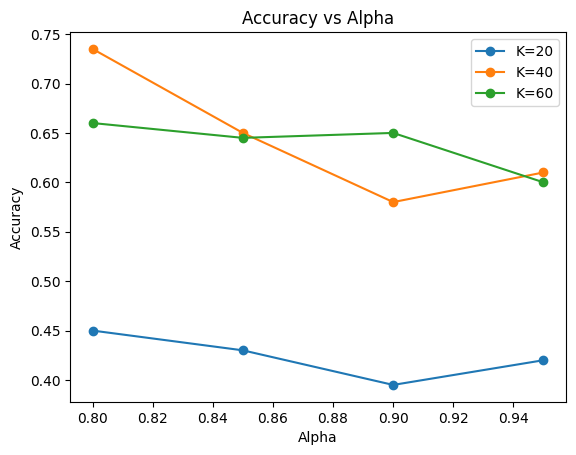

In [40]:
for K in K_values:
    alpha_list = []
    accs = []
    for result in results:
        if result[1] == K:
            alpha_list.append(result[0])
            accs.append(result[2])
    plt.plot(alpha_list, accs, marker='o', label=f'K={K}')
plt.xlabel("Alpha")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Alpha")
plt.legend()
plt.show()